In [1]:
import os
import sys
import time
import h5py
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Paths
THIS_DIR = os.getcwd()
MODULE_DIR = THIS_DIR  # unmerge/count_test_parentness
REPO_DIR = os.path.abspath(os.path.join(MODULE_DIR, '..', '..'))  # PracticeTagging

sys.path.insert(0, MODULE_DIR)

import tool  # noqa: E402
import importlib
from model import ParentnessCountTransformer  # noqa: E402

importlib.reload(tool)  # noqa: E402

# Reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Experiment output
RUN_NAME = 'ParentnessCount_missing'
OUT_DIR = os.path.join(MODULE_DIR, 'runs', RUN_NAME)
FIG_DIR = os.path.join(OUT_DIR, 'figs')
CKPT_DIR = os.path.join(OUT_DIR, 'ckpts')

tool.ensure_dir(FIG_DIR)
tool.ensure_dir(CKPT_DIR)

CONFIG = {
    'data_path': os.path.join(REPO_DIR, 'test.h5'),
    'n_jets': 50000,
    'max_particles': 100,
    'hlt_effects': {
        'pt_resolution': 0.10,
        'eta_resolution': 0.03,
        'phi_resolution': 0.03,
        'pt_threshold_offline': 0.5,
        'pt_threshold_hlt': 1.5,
        'merge_enabled': True,
        'merge_radius': 0.01,
        'efficiency_loss': 0.03,
    },
    'model': {
        'input_dim': 7,
        'embed_dim': 128,
        'num_heads': 8,
        'num_layers': 4,
        'ff_dim': 512,
        'dropout': 0.1,
        # Keep gradients alive for negative raw values.
        'softplus_beta': 0.2,
    },
    'training': {
        'batch_size': 256,
        'epochs': 60,
        'warmup_parent_epochs': 3,
        'lr': 5e-4,
        'weight_decay': 1e-5,
        'warmup_epochs': 3,
        'patience': 8,
        'grad_clip': 1.0,
        'huber_delta': 1.0,
        'thr_parent': 0.5,
        'w_parent': 1.0,
        'w_k': 1.0,
        'w_sum': 0.2,
        'neg_k_weight': 0.2,
    },
    'target': {
        # 'missing'   => k_true = group_size - 1 (net missing count contributed by each merged parent)
        # 'group_size'=> k_true = group_size
        'count_kind': 'missing',
        'max_k': None,
    },
    'io': {
        'run_name': RUN_NAME,
        'out_dir': OUT_DIR,
        'fig_dir': FIG_DIR,
        'ckpt_dir': CKPT_DIR,
        'config_path': os.path.join(OUT_DIR, 'config.json'),
        'ckpt_path': os.path.join(CKPT_DIR, 'parent_count.pt'),
        # If set to an existing file path, training will be skipped and weights reloaded.
        'load_model': None,
    },
}

tool.save_config(CONFIG, CONFIG['io']['config_path'])
print('Data path:', CONFIG['data_path'])
print('Run dir:', CONFIG['io']['out_dir'])

Device: cuda
Data path: d:\PracticeTagging\test.h5
Run dir: d:\PracticeTagging\unmerge\count_test_parentness\runs\ParentnessCount_missing


In [2]:
# Load data
n = int(CONFIG['n_jets'])
S = int(CONFIG['max_particles'])

with h5py.File(CONFIG['data_path'], 'r') as f:
    weights = f['weights'][:n].astype(np.float32)
    pt = f['fjet_clus_pt'][:n, :S].astype(np.float32)
    eta = f['fjet_clus_eta'][:n, :S].astype(np.float32)
    phi = f['fjet_clus_phi'][:n, :S].astype(np.float32)
    E = f['fjet_clus_E'][:n, :S].astype(np.float32)

constituents_raw = np.stack([pt, eta, phi, E], axis=-1)  # [N,S,4]
masks_raw = pt > 0

print('Raw:', constituents_raw.shape, 'mask:', masks_raw.shape)
print('weights:', weights.shape, 'mean=', float(weights.mean()))

Raw: (50000, 100, 4) mask: (50000, 100)
weights: (50000,) mean= 1.0007245540618896


In [3]:
# HLT simulation (with merge group_size) + offline threshold + 7D features
constituents_hlt, masks_hlt, masks_off, group_size = tool.apply_hlt_effects_with_groups(
    constituents_raw,
    masks_raw,
    CONFIG,
    seed=seed,
)

# Offline thresholded view (for feature standardization)
pt_thr_off = float(CONFIG['hlt_effects']['pt_threshold_offline'])
masks_off = masks_raw & (constituents_raw[:, :, 0] >= pt_thr_off)
constituents_off = constituents_raw.copy()
constituents_off[~masks_off] = 0

features_off = tool.compute_features(constituents_off, masks_off)
features_hlt = tool.compute_features(constituents_hlt, masks_hlt)
print('Features:', features_off.shape, features_hlt.shape)

# Split
idx = np.arange(features_hlt.shape[0])
train_idx, temp_idx = train_test_split(idx, test_size=0.3, random_state=seed)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=seed)
print(f"Split: train={len(train_idx):,} val={len(val_idx):,} test={len(test_idx):,}")

# Standardize using OFFLINE TRAIN stats
feat_means_off, feat_stds_off = tool.get_stats(features_off, masks_off, train_idx)
features_hlt_std = tool.standardize(features_hlt, masks_hlt, feat_means_off, feat_stds_off, clip=10.0)
print('Standardization done.')

Features: (50000, 100, 7) (50000, 100, 7)
Split: train=35,000 val=7,500 test=7,500
Standardization done.


In [4]:
# Build parentness + count targets from group_size
count_kind = str(CONFIG['target']['count_kind'])
max_k = CONFIG['target'].get('max_k', None)

parent_gt_all, k_true_all, jet_sum_true = tool.build_parent_targets(
    masks_hlt,
    group_size,
    count_kind=count_kind,
    max_k=max_k,
)

print('Target count_kind:', count_kind)
print('Parent pos frac (valid tokens):', float(parent_gt_all[masks_hlt].mean()))
print('Jet sum(k) true: mean=', float(jet_sum_true.mean()), 'p99=', float(np.percentile(jet_sum_true, 99)))

# Quick check: group_size distribution (for merged parents only)
merged_sizes = group_size[(masks_hlt) & (group_size > 1)].astype(np.int32)
if merged_sizes.size > 0:
    print('Merged parent group_size: mean=', float(merged_sizes.mean()), 'max=', int(merged_sizes.max()))



Target count_kind: missing
Parent pos frac (valid tokens): 0.47932031750679016
Jet sum(k) true: mean= 20.823259353637695 p99= 47.0
Merged parent group_size: mean= 2.366689244356234 max= 18


Saved figure: d:\PracticeTagging\unmerge\count_test_parentness\runs\ParentnessCount_missing\figs\target_sumk_missing.png


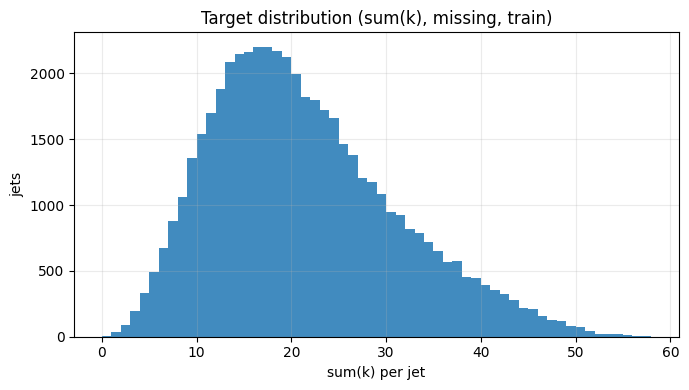

In [5]:
# Visualize target distribution (saved)
fig_path = os.path.join(CONFIG['io']['fig_dir'], f"target_sumk_{count_kind}.png")
plt.figure(figsize=(7, 4))
plt.hist(jet_sum_true, bins=int(max(jet_sum_true)), alpha=0.85)
plt.title(f"Target distribution (sum(k), {count_kind}, train)")
plt.xlabel('sum(k) per jet')
plt.ylabel('jets')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(fig_path, dpi=160, bbox_inches='tight')
print('Saved figure:', fig_path)
plt.show()

In [6]:
# Datasets / Loaders
BS = int(CONFIG['training']['batch_size'])

train_ds = tool.JetParentCountDataset(train_idx, features_hlt_std, masks_hlt, parent_gt_all, k_true_all, jet_sum_true)
val_ds = tool.JetParentCountDataset(val_idx, features_hlt_std, masks_hlt, parent_gt_all, k_true_all, jet_sum_true)
test_ds = tool.JetParentCountDataset(test_idx, features_hlt_std, masks_hlt, parent_gt_all, k_true_all, jet_sum_true)

train_loader = DataLoader(train_ds, batch_size=BS, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BS)
test_loader = DataLoader(test_ds, batch_size=BS)

# Parentness pos_weight (token-level) computed on TRAIN split
pos = float(parent_gt_all[train_idx][masks_hlt[train_idx]].sum())
neg = float(masks_hlt[train_idx].sum() - parent_gt_all[train_idx][masks_hlt[train_idx]].sum())
parent_pos_weight = (neg / max(pos, 1.0))
print(f"Parentness stats (train tokens): pos={int(pos):,} neg={int(neg):,} suggested_pos_weight={parent_pos_weight:.2f}")

Parentness stats (train tokens): pos=534,336 neg=576,565 suggested_pos_weight=1.08


In [7]:
# Build model

# Initialize count head bias near a reasonable prior (on merged parents only)
if (parent_gt_all[train_idx] > 0.5).any():
    init_k_bias = float(k_true_all[train_idx][parent_gt_all[train_idx] > 0.5].mean())
else:
    init_k_bias = 0.5

mcfg = CONFIG['model']
model = ParentnessCountTransformer(
    input_dim=int(mcfg['input_dim']),
    embed_dim=int(mcfg['embed_dim']),
    num_heads=int(mcfg['num_heads']),
    num_layers=int(mcfg['num_layers']),
    ff_dim=int(mcfg['ff_dim']),
    dropout=float(mcfg['dropout']),
    softplus_beta=float(mcfg.get('softplus_beta', 0.2)),
    init_k_bias=init_k_bias,
).to(device)

print('init_k_bias:', init_k_bias)
print('Model params:', sum(p.numel() for p in model.parameters()) / 1e6, 'M')

d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


init_k_bias: 1.3672465085983276
Model params: 0.811394 M


In [8]:
# Train or reload
io = CONFIG['io']
load_path = io.get('load_model', None)

train_cfg = tool.TrainCfg(**CONFIG['training'])

if load_path is not None and os.path.exists(load_path):
    print('Loading model from:', load_path)
    tool.load_checkpoint(model, load_path, map_location=device)
else:
    print('Training...')
    t0 = time.time()
    model, info = tool.train_parent_count(
        model,
        train_loader,
        val_loader,
        device,
        train_cfg,
        parent_pos_weight=float(parent_pos_weight),
        ckpt_path=io['ckpt_path'],
    )
    print('Training done. time=', time.time() - t0, 's')
    print('Best scalar:', info.get('best_scalar'))

# Save final snapshot
final_ckpt = os.path.join(io['ckpt_dir'], 'parent_count_final.pt')
tool.save_checkpoint(model, final_ckpt, extra={'parent_pos_weight': float(parent_pos_weight)})
print('Saved final checkpoint:', final_ckpt)

Training...
[Parent+Count] Ep 001: train_loss=0.4659 val_parent=0.4318 val_k=0.2544 val_sum_mae=62.747 prec=0.751 rec=0.912 no_improve=0
[Parent+Count] Ep 002: train_loss=0.4387 val_parent=0.4256 val_k=0.2562 val_sum_mae=58.850 prec=0.761 rec=0.902 no_improve=0
[Parent+Count] Ep 003: train_loss=0.4321 val_parent=0.4289 val_k=0.2435 val_sum_mae=61.994 prec=0.748 rec=0.927 no_improve=1
[Parent+Count] Ep 004: train_loss=1.5637 val_parent=0.4306 val_k=0.2273 val_sum_mae=3.491 prec=0.760 rec=0.902 no_improve=0
[Parent+Count] Ep 005: train_loss=1.2989 val_parent=0.4286 val_k=0.2241 val_sum_mae=3.485 prec=0.754 rec=0.915 no_improve=0
[Parent+Count] Ep 006: train_loss=1.2720 val_parent=0.4398 val_k=0.2185 val_sum_mae=3.816 prec=0.747 rec=0.925 no_improve=1
[Parent+Count] Ep 007: train_loss=1.2663 val_parent=0.4233 val_k=0.2243 val_sum_mae=3.464 prec=0.758 rec=0.914 no_improve=0
[Parent+Count] Ep 008: train_loss=1.2593 val_parent=0.4289 val_k=0.2227 val_sum_mae=3.499 prec=0.753 rec=0.921 no_imp

Saved figure: d:\PracticeTagging\unmerge\count_test_parentness\runs\ParentnessCount_missing\figs\parentness_pr_sweep.png


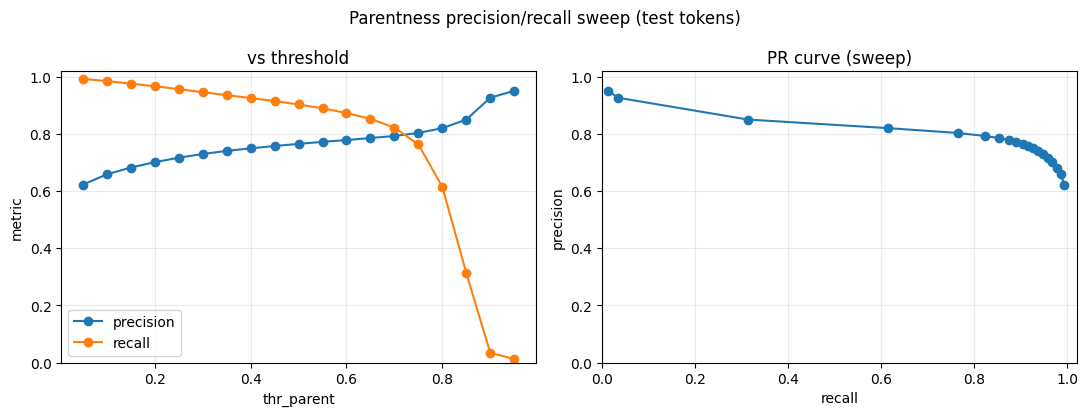

Saved figure: d:\PracticeTagging\unmerge\count_test_parentness\runs\ParentnessCount_missing\figs\k_pos_diagnostics.png


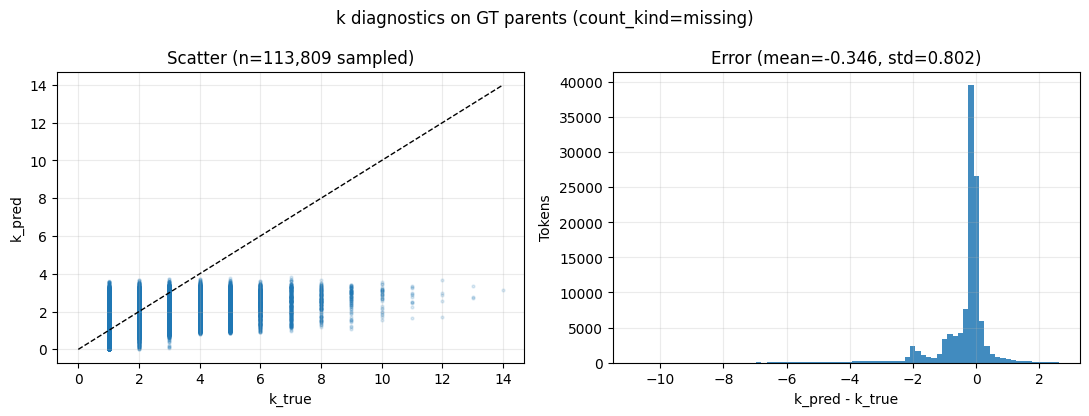

In [9]:
# Extra diagnostics: parentness threshold sweep + k on GT parents

# Collect token-level outputs on TEST split (may take a moment)
out_tok = tool.collect_token_outputs(model, test_loader, device)

# Parentness sweep
sweep = tool.sweep_parent_thresholds(out_tok['parent_prob'], out_tok['parent_gt'], out_tok['mask'])
pr_path = os.path.join(CONFIG['io']['fig_dir'], 'parentness_pr_sweep.png')
tool.plot_parent_pr_sweep(
    sweep,
    title='Parentness precision/recall sweep (test tokens)',
    save_path=pr_path,
    dpi=160,
)

# k diagnostics on GT parents only
k_path = os.path.join(CONFIG['io']['fig_dir'], 'k_pos_diagnostics.png')
tool.plot_k_pos_diagnostics(
    out_tok['k_pred'],
    out_tok['k_true'],
    out_tok['parent_gt'],
    out_tok['mask'],
    title=f"k diagnostics on GT parents (count_kind={count_kind})",
    max_points=200_000,
    seed=seed,
    save_path=k_path,
    dpi=160,
)

In [10]:
# Evaluate on test split + plots

val_metrics = tool.eval_parentness_and_count(
    model,
    val_loader,
    device,
    pos_weight=float(parent_pos_weight),
    thr_parent=float(train_cfg.thr_parent),
    huber_delta=float(train_cfg.huber_delta),
    neg_k_weight=float(train_cfg.neg_k_weight),
)
test_metrics = tool.eval_parentness_and_count(
    model,
    test_loader,
    device,
    pos_weight=float(parent_pos_weight),
    thr_parent=float(train_cfg.thr_parent),
    huber_delta=float(train_cfg.huber_delta),
    neg_k_weight=float(train_cfg.neg_k_weight),
)
print('Val metrics:', val_metrics)
print('Test metrics:', test_metrics)

pred_sum, true_sum, parent_prob = tool.predict_on_loader(model, test_loader, device)



Val metrics: {'parent_loss': 0.4176321158806483, 'k_loss': 0.22439832538366317, 'precision': 0.7656652679267704, 'recall': 0.9069579216848921, 'sum_mae': 3.3772715091705323, 'mae_k_pos': 0.4581681619087855, 'tp': 103093.0, 'fp': 31552.0, 'fn': 10576.0, 'n_pos_tokens': 113669.0, 'n_jets': 7500.0}
Test metrics: {'parent_loss': 0.41484839220841724, 'k_loss': 0.224393796424071, 'precision': 0.7659137271251806, 'recall': 0.9039355411259214, 'sum_mae': 3.4022984902064004, 'mae_k_pos': 0.4598690936962763, 'tp': 102876.0, 'fp': 31442.0, 'fn': 10933.0, 'n_pos_tokens': 113809.0, 'n_jets': 7500.0}


Saved figure: d:\PracticeTagging\unmerge\count_test_parentness\runs\ParentnessCount_missing\figs\sumk_pred_true.png


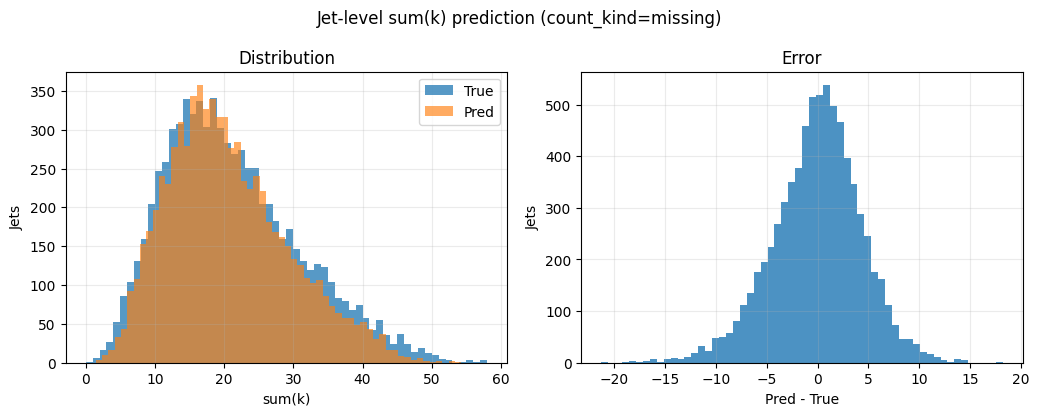

Saved figure: d:\PracticeTagging\unmerge\count_test_parentness\runs\ParentnessCount_missing\figs\sumk_scatter.png


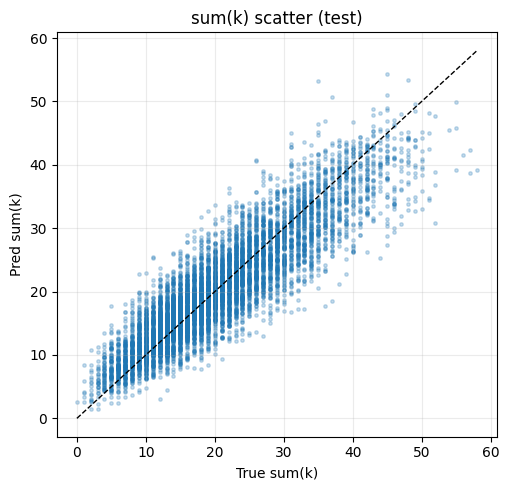

In [11]:
fig_path = os.path.join(CONFIG['io']['fig_dir'], 'sumk_pred_true.png')
tool.plot_sum_predictions(
    pred_sum,
    true_sum,
    title=f"Jet-level sum(k) prediction (count_kind={count_kind})",
    bins=int(max(jet_sum_true)),
    save_path=fig_path,
    dpi=160,
)

# Scatter plot
sc_path = os.path.join(CONFIG['io']['fig_dir'], 'sumk_scatter.png')
plt.figure(figsize=(5.2, 5.0))
plt.scatter(true_sum, pred_sum, s=6, alpha=0.25)
mx = float(max(true_sum.max(), pred_sum.max(), 1.0))
plt.plot([0, mx], [0, mx], 'k--', linewidth=1)
plt.xlabel('True sum(k)')
plt.ylabel('Pred sum(k)')
plt.title('sum(k) scatter (test)')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(sc_path, dpi=160, bbox_inches='tight')
print('Saved figure:', sc_path)
plt.show()